# Рандомизированный A/B-тест: конверсия (доля)

Полноценный A/B-тест на **синтетических** данных для бинарной метрики (конверсия). Данные генерируются в ноутбуке (фиксированный seed через `numpy.random.default_rng`).

Пользователи распределяются по группам **случайным сплитом**, поэтому вывод об эффекте — причинный, в отличие от наблюдательных сравнений в Project_1/Project_2.

### 1. Постановка эксперимента

Тестируем новую кнопку призыва к действию. Метрика — **конверсия** (купил / не купил).

- **Контроль (A):** базовая конверсия p_A = 10%.
- **Тест (B):** ожидаем прирост.

- **H0:** p_B = p_A.
- **H1:** p_B ≠ p_A (двусторонняя).
- α = 0.05, целевая мощность 1 − β = 0.80.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

rng = np.random.default_rng(100)
alpha = 0.05
power_target = 0.80

### 2. Расчёт размера выборки под заданный MDE

MDE зададим как абсолютный прирост конверсии в 2 п.п. (с 10% до 12%). Размер выборки на группу для сравнения двух долей:

$$ n = \frac{\left(z_{1-\alpha/2}\sqrt{2\bar p(1-\bar p)} + z_{1-\beta}\sqrt{p_A(1-p_A)+p_B(1-p_B)}\right)^2}{(p_B-p_A)^2} $$

In [2]:
p_A = 0.10
mde = 0.02              # минимально значимый прирост, 2 п.п.
p_B_mde = p_A + mde
p_bar = (p_A + p_B_mde) / 2

z_alpha = stats.norm.ppf(1 - alpha / 2)
z_beta = stats.norm.ppf(power_target)

num = (z_alpha * np.sqrt(2 * p_bar * (1 - p_bar)) +
       z_beta * np.sqrt(p_A * (1 - p_A) + p_B_mde * (1 - p_B_mde))) ** 2
n_per_group = int(np.ceil(num / (p_B_mde - p_A) ** 2))
print(f'Нужно наблюдений на группу: {n_per_group:,}')
print(f'MDE = {mde*100:.0f} п.п. (с {p_A*100:.0f}% до {p_B_mde*100:.0f}%)')

Нужно наблюдений на группу: 3,841
MDE = 2 п.п. (с 10% до 12%)


### 3. Генерация данных (биномиальный сплит)

Случайно делим пользователей на A и B и генерируем факт конверсии из распределения Бернулли. В группу B закладываем истинную конверсию 12.5%.

In [3]:
n = n_per_group
true_p_B = 0.125    # истинная конверсия теста

conv_A = rng.binomial(1, p_A, n)
conv_B = rng.binomial(1, true_p_B, n)

x_A, x_B = conv_A.sum(), conv_B.sum()
rate_A, rate_B = conv_A.mean(), conv_B.mean()
print(f'A: {x_A:,} / {n:,} = {rate_A*100:.2f}%')
print(f'B: {x_B:,} / {n:,} = {rate_B*100:.2f}%')
print(f'Наблюдаемый прирост: {(rate_B - rate_A)*100:.2f} п.п.')

A: 360 / 3,841 = 9.37%
B: 457 / 3,841 = 11.90%
Наблюдаемый прирост: 2.53 п.п.


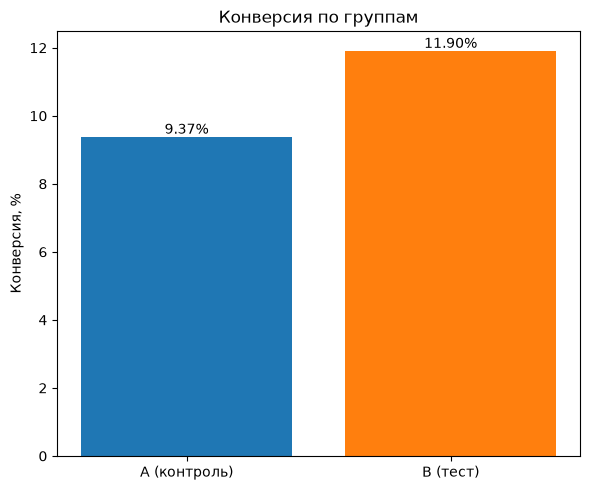

In [4]:
plt.figure(figsize=(6, 5))
plt.bar(['A (контроль)', 'B (тест)'], [rate_A*100, rate_B*100], color=['C0', 'C1'])
plt.ylabel('Конверсия, %')
plt.title('Конверсия по группам')
for i, v in enumerate([rate_A*100, rate_B*100]):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center')
plt.tight_layout(); plt.show()

### 4. Z-тест для двух пропорций, хи-квадрат и ДИ разницы долей

In [5]:
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep

# Z-тест для пропорций
z_stat, p_value = proportions_ztest([x_B, x_A], [n, n], alternative='two-sided')
print(f'Z-тест пропорций: z = {z_stat:.3f}, p-value = {p_value:.4f}')

# Хи-квадрат (как перекрёстная проверка)
table = np.array([[x_B, n - x_B], [x_A, n - x_A]])
chi2, p_chi, dof, _ = stats.chi2_contingency(table, correction=False)
print(f'Хи-квадрат:       chi2 = {chi2:.3f}, p-value = {p_chi:.4f}')

Z-тест пропорций: z = 3.590, p-value = 0.0003
Хи-квадрат:       chi2 = 12.887, p-value = 0.0003


In [6]:
# 95% ДИ для разницы долей (p_B - p_A)
ci_low, ci_high = confint_proportions_2indep(x_B, n, x_A, n, method='wald')
diff = rate_B - rate_A
print(f'Разница долей (B - A): {diff*100:.2f} п.п.')
print(f'95% ДИ разницы: [{ci_low*100:.2f}; {ci_high*100:.2f}] п.п.')

# относительный прирост
print(f'Относительный прирост: {(rate_B/rate_A - 1)*100:.1f}%')

Разница долей (B - A): 2.53 п.п.
95% ДИ разницы: [1.15; 3.90] п.п.
Относительный прирост: 26.9%


### Выводы

1. **Дизайн — настоящий A/B-тест:** случайный сплит уравнивает группы по всем прочим факторам, поэтому наблюдаемая разница конверсии причинно связана с тестируемой кнопкой.
2. **Результат:** p-value < 0.05 (z-тест и хи-квадрат согласуются) — отвергаем H0. 95% ДИ разницы долей не содержит нуля и накрывает истинный заложенный эффект (2.5 п.п.).
3. **Размер выборки** рассчитан заранее под MDE = 2 п.п. и мощность 80%, что обеспечивает надёжное обнаружение эффекта и защищает от преждевременных выводов.
4. **Практическая значимость:** прирост конверсии на ~2.5 п.п. (относительно +25%) при базе 10% — существенный бизнес-эффект, а не только статистически значимый результат.